# Job posts through the preprocessor

The same questions as `analysis.ipynb` (volume, location, pay, occupations, visas), answered with the project's own pipeline instead of ad-hoc regexes:

- `load_messages` reads `data/raw`, drops media-only posts and collapses reposts of the same ad.
- `build_preprocessor` turns each post into the model's feature matrix. Location, pay and post-structure numbers below are decoded from that matrix, so the charts show what a model trained on it would see.

Like `analysis.ipynb`, this describes posts in Uzbek-language Telegram groups, not the Korean labour market, and says nothing about individual workers' legal status. Every figure is also saved to `results/`.

In [1]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "preprocess.py").is_file():
        PROJECT_ROOT = candidate
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find the project root")

import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MultipleLocator, PercentFormatter
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

from config.settings import settings
from src.preprocess import (
    CATEGORICAL_FEATURES, NUMERIC_FEATURES, build_preprocessor, load_messages, numeric_post_features,
)
from src.utils.post_parsing import post_body
from src.utils.salary import PERIOD_RANGES

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Categorical slots 1-3 of the reference palette, grey for context, hairline chrome.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7"
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": ["Helvetica Neue", "Apple SD Gothic Neo", "sans-serif"], "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.edgecolor": GREY, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": GREY, "ytick.color": GREY, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False,
})
pd.set_option("display.max_columns", 30)

thousands = FuncFormatter(lambda value, _: f"{value:,.0f}")
krw = FuncFormatter(lambda value, _: f"{value / 1e6:g}M" if value >= 1e6 else f"{value / 1e3:g}k")


def titled(ax, title, note=None):
    ax.set_title(title, pad=24 if note else 8)
    if note:
        ax.text(0, 1.02, note, transform=ax.transAxes, color=MUTED, fontsize=9, va="bottom")


def save(fig, name):
    fig.savefig(RESULTS_DIR / f"{name}.png", dpi=200, bbox_inches="tight")


def kst(dates, freq):
    """Calendar period in Korean time, where the posts are written."""
    return dates.dt.tz_convert("Asia/Seoul").dt.tz_localize(None).dt.to_period(freq)

## 1. Load and deduplicate

In [2]:
# RAW_DATA_DIR in .env may be relative to the project root, not to this notebook.
all_posts = load_messages(PROJECT_ROOT / settings.raw_data_dir, drop_reposts=False)
posts = all_posts.loc[~all_posts["is_repost"]].reset_index(drop=True)

print(f"Posts with text: {len(all_posts):,}")
print(f"Unique ads:      {len(posts):,}  ({all_posts['is_repost'].sum():,} reposts dropped)")
print(f"Dates:           {posts['date'].min():%Y-%m-%d} to {posts['date'].max():%Y-%m-%d}")

Posts with text: 191,083
Unique ads:      146,757  (44,326 reposts dropped)
Dates:           2021-01-01 to 2026-10-03


## 2. Run the preprocessor

One row per unique ad. The four branches of the `ColumnTransformer` sit side by side in `X`.

In [3]:
preprocessor = build_preprocessor()
X = preprocessor.fit_transform(posts[["text", "source_file"]])
BRANCHES = ["words", "chars", "numeric", "categorical"]


def block(name):
    """Columns of X produced by one branch of the ColumnTransformer."""
    return X[:, preprocessor.output_indices_[name]]


print(f"X: {X.shape[0]:,} ads x {X.shape[1]:,} columns, {X.nnz / (X.shape[0] * X.shape[1]):.2%} non-zero")
pd.DataFrame(
    {
        "columns": [block(name).shape[1] for name in BRANCHES],
        "non_zero_per_ad": [block(name).getnnz(axis=1).mean() for name in BRANCHES],
    },
    index=BRANCHES,
).round(1)

X: 146,757 ads x 100,039 columns, 0.26% non-zero


,columns,non_zero_per_ad
words,50000,18.3
chars,50000,230.0
numeric,12,12.0
categorical,27,3.0


Decode the numeric and categorical branches back to their original units (undo the scaler and the one-hot encoder). Provinces with fewer than 20 ads were folded into one infrequent column by the encoder; they show up as `other`.

In [4]:
numeric = preprocessor.named_transformers_["numeric"][-1].inverse_transform(block("numeric").toarray())
categorical = preprocessor.named_transformers_["categorical"][-1].inverse_transform(block("categorical"))

features = pd.concat(
    [
        posts[["date", "source_file", "repost_count"]],
        pd.DataFrame(numeric, columns=NUMERIC_FEATURES),
        pd.DataFrame(categorical, columns=CATEGORICAL_FEATURES).replace("infrequent_sklearn", "other"),
    ],
    axis=1,
)
FLAGS = ["has_phone", "has_url", "is_forwarded", "is_filled", "has_salary"]
features[FLAGS] = features[FLAGS].round().astype(bool)
features[["n_lines", "n_emoji"]] = features[["n_lines", "n_emoji"]].round().astype(int)
features["salary_krw"] = np.expm1(features["log_salary_krw"]).round().where(features["has_salary"])
features["n_chars"] = np.expm1(features["log_length"]).round().astype(int)
features["month"] = kst(features["date"], "M")

# The decoded values must match what the feature function computes from the raw text.
sample = posts.sample(500, random_state=0)
assert np.allclose(
    numeric_post_features(sample["text"]).to_numpy(),
    features.loc[sample.index, NUMERIC_FEATURES].astype(float).to_numpy(),
    atol=1e-5,
)
NO_PROVINCE = ["Nationwide", "unknown", "other"]

features[["month", "province", "location_source", "salary_period", "salary_krw", "n_chars", "is_forwarded"]].head()

,month,province,location_source,salary_period,salary_krw,n_chars,is_forwarded
0,2026-09,Gyeonggi-do,group,none,NaN,211,False
1,2026-09,Gyeonggi-do,group,none,NaN,23,False
2,2026-09,Gyeonggi-do,group,none,NaN,18,False
3,2026-09,Gyeonggi-do,group,none,NaN,53,False
4,2026-09,Gyeonggi-do,group,none,NaN,35,False


## 3. Volume

Since August 2026 the data also holds posts that the Ish e'lonlari bot forwards from many groups. They are plotted separately so the jump is not read as growth in jobs.

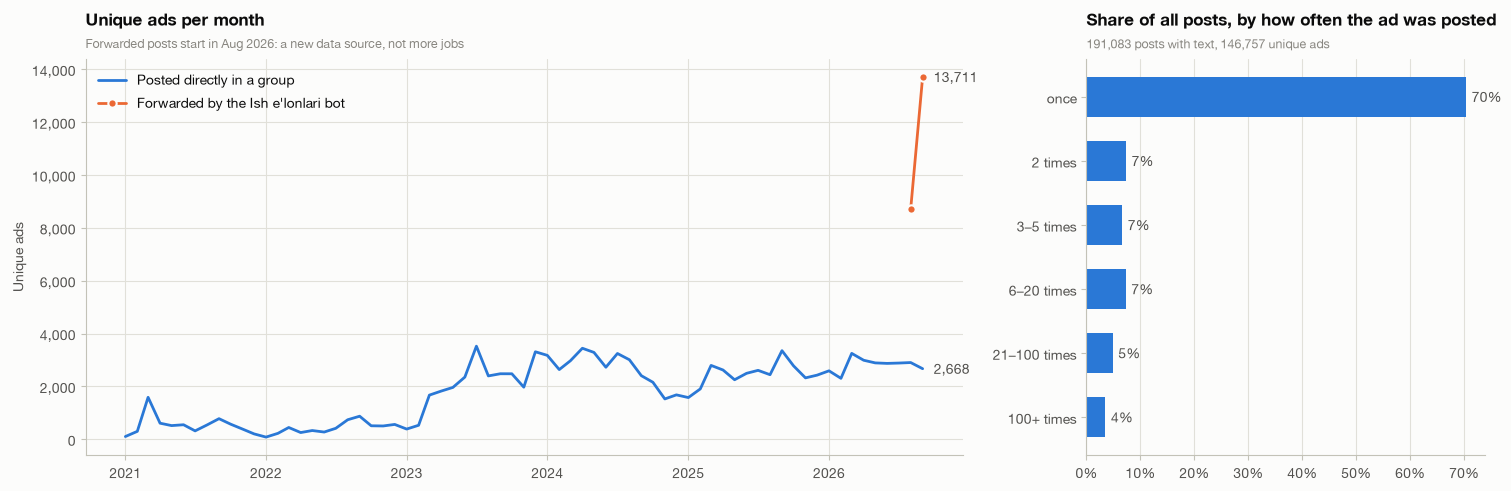

,unique_ads,posts,share_of_posts
repost_count,,,
once,134469,134469,0.703720
2 times,7012,14024,0.073392
3–5 times,3518,12658,0.066243
6–20 times,1480,13907,0.072780
21–100 times,254,9313,0.048738
100+ times,24,6712,0.035126


In [5]:
complete = features["month"] < features["month"].max()  # the newest month is still being crawled
volume = (
    features[complete]
    .groupby(["month", "is_forwarded"]).size().unstack(fill_value=0)
    .rename(columns={False: "direct", True: "forwarded"})
)

REPOST_BINS = [0, 1, 2, 5, 20, 100, np.inf]
REPOST_LABELS = ["once", "2 times", "3–5 times", "6–20 times", "21–100 times", "100+ times"]
reposts = pd.DataFrame({
    "unique_ads": pd.cut(posts["repost_count"], REPOST_BINS, labels=REPOST_LABELS).value_counts(sort=False),
    "posts": pd.cut(all_posts["repost_count"], REPOST_BINS, labels=REPOST_LABELS).value_counts(sort=False),
})
reposts["share_of_posts"] = reposts["posts"] / reposts["posts"].sum()

fig, (ax_month, ax_repost) = plt.subplots(1, 2, figsize=(15, 4.8), width_ratios=[2.2, 1], constrained_layout=True)
x = volume.index.to_timestamp()
for column, color, label in [
    ("direct", BLUE, "Posted directly in a group"),
    ("forwarded", ORANGE, "Forwarded by the Ish e'lonlari bot"),
]:
    series = volume[column].where(volume[column] > 0)
    ax_month.plot(x, series, color=color, label=label, marker="o" if column == "forwarded" else None,
                  markersize=6, markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax_month.annotate(f"{series.iloc[-1]:,.0f}", (x[-1], series.iloc[-1]), xytext=(8, 0),
                      textcoords="offset points", va="center", color=INK_2)
ax_month.yaxis.set_major_formatter(thousands)
ax_month.set_ylabel("Unique ads")
ax_month.legend(loc="upper left")
titled(ax_month, "Unique ads per month", "Forwarded posts start in Aug 2026: a new data source, not more jobs")

bars = ax_repost.barh(reposts.index.astype(str), reposts["share_of_posts"], color=BLUE, height=0.62)
ax_repost.bar_label(bars, labels=[f"{share:.0%}" for share in reposts["share_of_posts"]], padding=4, color=INK_2)
ax_repost.invert_yaxis()
ax_repost.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax_repost.grid(axis="y", visible=False)
titled(ax_repost, "Share of all posts, by how often the ad was posted",
       f"{len(all_posts):,} posts with text, {len(posts):,} unique ads")
save(fig, "01_volume")
plt.show()
reposts

## 4. Location

The preprocessor resolves a province in order: a Korean address in the post, a place name written in Latin or Cyrillic letters, and finally the location of the group the post came from.

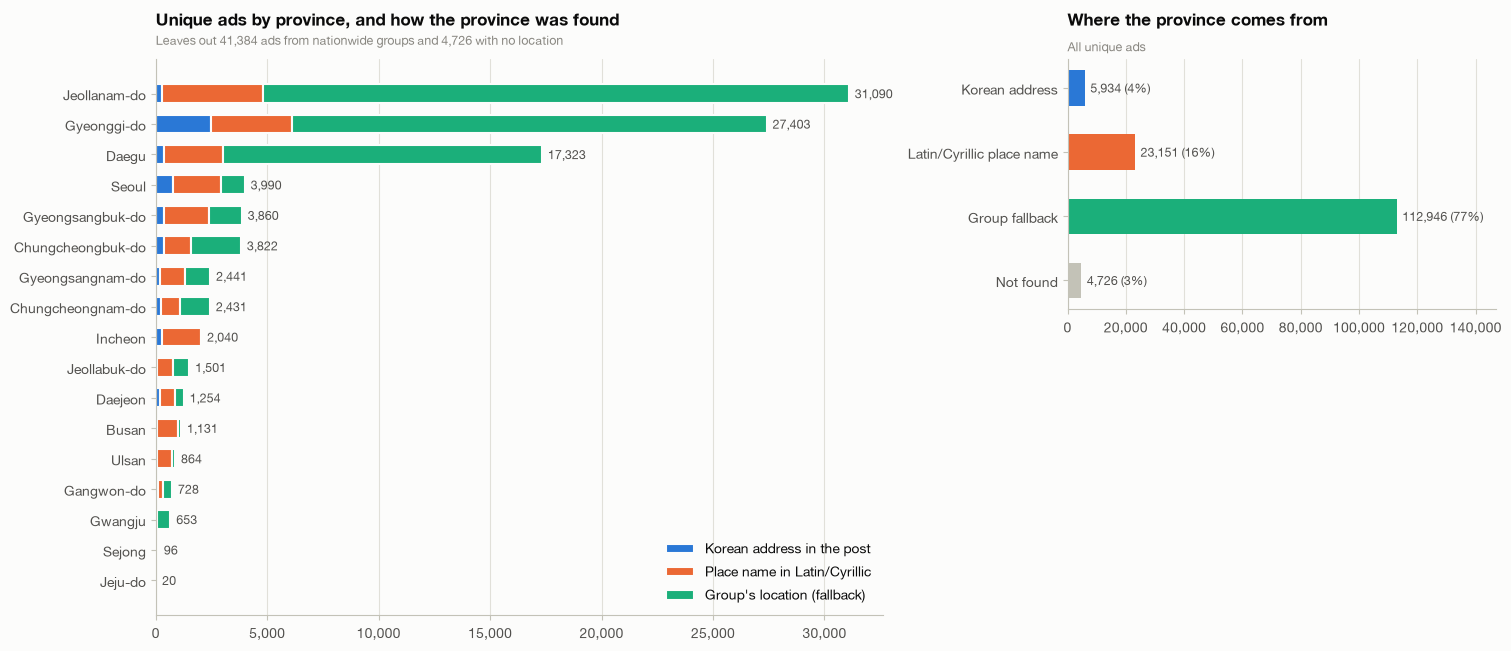

location_source,address,text,group,total
province,,,,
Jeollanam-do,296,4524,26270,31090
Gyeonggi-do,2492,3608,21303,27403
Daegu,371,2661,14291,17323
Seoul,795,2128,1067,3990
Gyeongsangbuk-do,351,2023,1486,3860
Chungcheongbuk-do,389,1172,2261,3822
Gyeongsangnam-do,184,1137,1120,2441
Chungcheongnam-do,232,865,1334,2431
Incheon,289,1741,10,2040


In [6]:
SOURCES = {
    "address": (BLUE, "Korean address in the post"),
    "text": (ORANGE, "Place name in Latin/Cyrillic"),
    "group": (AQUA, "Group's location (fallback)"),
}
located = features[~features["province"].isin(NO_PROVINCE)]
by_province = pd.crosstab(located["province"], located["location_source"]).reindex(columns=list(SOURCES), fill_value=0)
by_province = by_province.loc[by_province.sum(axis=1).sort_values().index]
sources = features["location_source"].value_counts().reindex(["address", "text", "group", "unknown"], fill_value=0)

fig, axes = plt.subplot_mosaic([["province", "source"], ["province", "."]], figsize=(15, 6.4), width_ratios=[1.7, 1],
                               height_ratios=[1, 1.1], constrained_layout=True)
ax_province, ax_source = axes["province"], axes["source"]
left = np.zeros(len(by_province))
for source, (color, label) in SOURCES.items():
    ax_province.barh(by_province.index, by_province[source], left=left, height=0.62, color=color,
                     edgecolor=SURFACE, linewidth=1.5, label=label)
    left += by_province[source].to_numpy()
for y, total in enumerate(left):
    ax_province.text(total, y, f"  {total:,.0f}", va="center", color=INK_2, fontsize=9)
ax_province.xaxis.set_major_formatter(thousands)
ax_province.grid(axis="y", visible=False)
ax_province.legend(loc="lower right")
nationwide = (features["province"] == "Nationwide").sum()
titled(ax_province, "Unique ads by province, and how the province was found",
       f"Leaves out {nationwide:,} ads from nationwide groups and {sources['unknown']:,} with no location")

bars = ax_source.barh(["Korean address", "Latin/Cyrillic place name", "Group fallback", "Not found"], sources,
                      color=[BLUE, ORANGE, AQUA, GREY], height=0.55)
ax_source.bar_label(bars, labels=[f"{count:,} ({count / len(features):.0%})" for count in sources], padding=4,
                    color=INK_2, fontsize=9)
ax_source.invert_yaxis()
ax_source.xaxis.set_major_formatter(thousands)
ax_source.set_xlim(0, sources.max() * 1.3)
ax_source.grid(axis="y", visible=False)
titled(ax_source, "Where the province comes from", "All unique ads")
save(fig, "02_location")
plt.show()
by_province.iloc[::-1].assign(total=lambda frame: frame.sum(axis=1))

## 5. Pay

`main_salary` keeps the first amount with a stated period, else the first amount whose size fits a period (hourly 9k–30k, daily 50k–500k, monthly 1M–8M KRW). The three periods have different scales, so each gets its own panel.

Ads with a salary: 10,069 of 146,757 (6.9%)


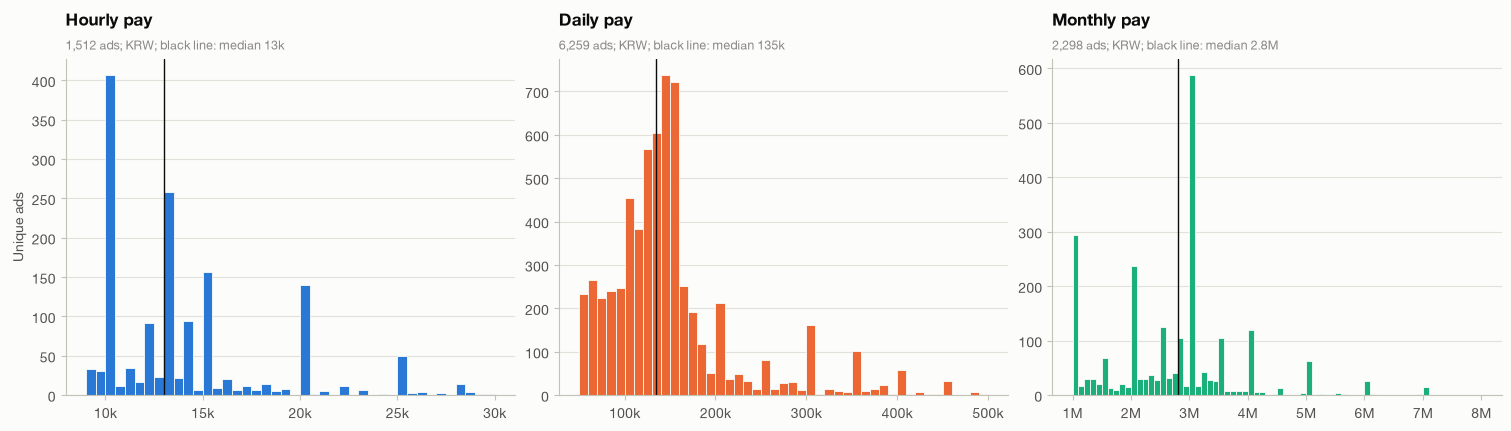

,count,mean,std,min,25%,50%,75%,max
salary_period,,,,,,,,
daily,6259.0,146582.0,73159.0,50000.0,100000.0,135000.0,160000.0,490000.0
hourly,1512.0,13929.0,4357.0,9000.0,10030.0,13000.0,15000.0,29850.0
monthly,2298.0,2657486.0,1118489.0,1000000.0,2000000.0,2800000.0,3000000.0,7000000.0


In [7]:
PERIODS = {"hourly": BLUE, "daily": ORANGE, "monthly": AQUA}
BIN_WIDTH = {"hourly": 500, "daily": 10_000, "monthly": 100_000}
paid = features.dropna(subset=["salary_krw"])
print(f"Ads with a salary: {len(paid):,} of {len(features):,} ({len(paid) / len(features):.1%})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for ax, (period, color) in zip(axes, PERIODS.items()):
    amounts = paid.loc[paid["salary_period"] == period, "salary_krw"]
    low, high = PERIOD_RANGES[period]
    ax.hist(amounts, bins=np.arange(low, high + BIN_WIDTH[period], BIN_WIDTH[period]), color=color,
            edgecolor=SURFACE, linewidth=0.6)
    median = amounts.median()
    ax.axvline(median, color=INK, linewidth=1)
    ax.xaxis.set_major_formatter(krw)
    ax.yaxis.set_major_formatter(thousands)
    ax.grid(axis="x", visible=False)
    titled(ax, f"{period.capitalize()} pay", f"{len(amounts):,} ads; KRW; black line: median {krw(median)}")
axes[0].set_ylabel("Unique ads")
save(fig, "03_pay_distribution")
plt.show()
paid.groupby("salary_period")["salary_krw"].describe(percentiles=[0.25, 0.5, 0.75]).round(0)

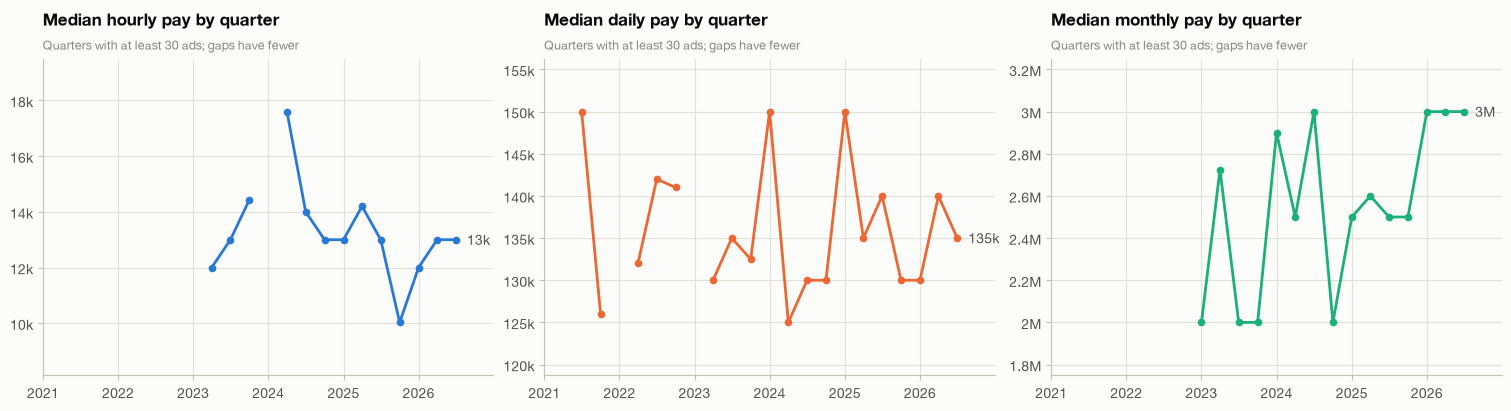

In [8]:
quarterly = (
    paid.assign(quarter=kst(paid["date"], "Q"))
    .groupby(["salary_period", "quarter"])["salary_krw"].agg(ads="size", median="median")
    .reset_index()
)
quarterly = quarterly[(quarterly["ads"] >= 30) & (quarterly["quarter"] < quarterly["quarter"].max())]

quarters = pd.period_range(quarterly["quarter"].min(), quarterly["quarter"].max(), freq="Q")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, constrained_layout=True)
for ax, (period, color) in zip(axes, PERIODS.items()):
    medians = quarterly[quarterly["salary_period"] == period].set_index("quarter")["median"].reindex(quarters)
    x = medians.index.to_timestamp()
    ax.plot(x, medians, color=color, marker="o", markersize=5.5, markeredgewidth=0)
    last_x, last_y = medians.dropna().index[-1].to_timestamp(), medians.dropna().iloc[-1]
    ax.annotate(krw(last_y), (last_x, last_y), xytext=(8, 0), textcoords="offset points", va="center", color=INK_2)
    ax.yaxis.set_major_formatter(krw)
    ax.margins(x=0.1, y=0.25)
    titled(ax, f"Median {period} pay by quarter", "Quarters with at least 30 ads; gaps have fewer")
save(fig, "04_pay_trend")
plt.show()

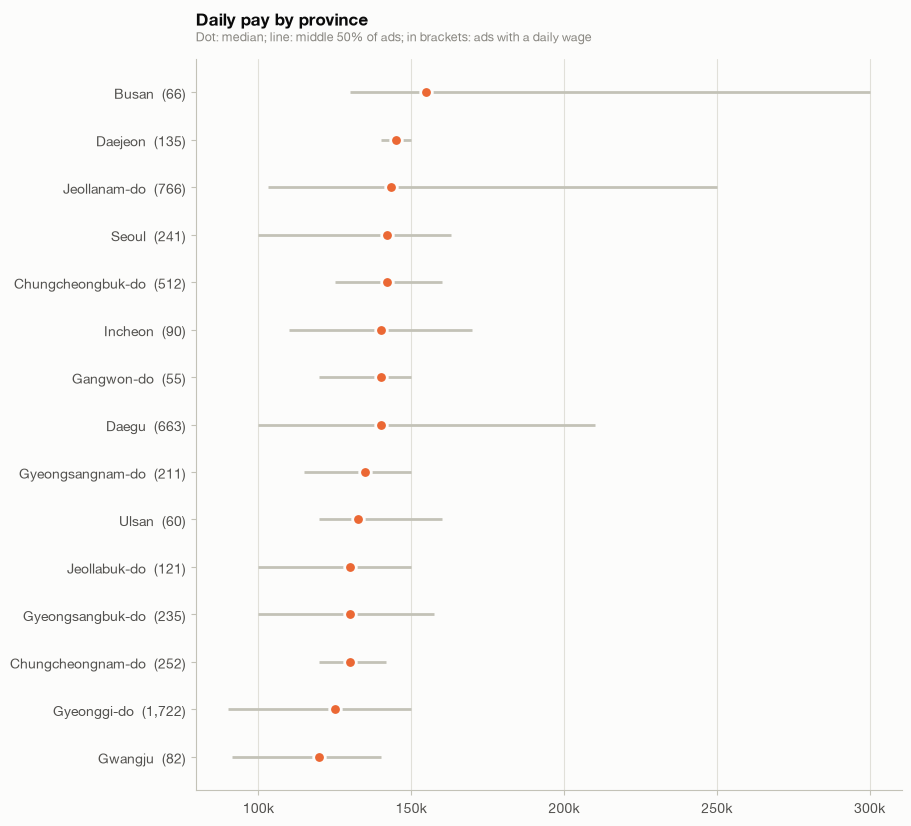

In [9]:
daily = paid[(paid["salary_period"] == "daily") & ~paid["province"].isin(NO_PROVINCE)]
daily_by_province = (
    daily.groupby("province")["salary_krw"].describe()[["count", "25%", "50%", "75%"]]
    .query("count >= 50").sort_values("50%")
)

fig, ax = plt.subplots(figsize=(9, 0.45 * len(daily_by_province) + 1.4), constrained_layout=True)
y = np.arange(len(daily_by_province))
ax.hlines(y, daily_by_province["25%"], daily_by_province["75%"], color=GREY, linewidth=2)
ax.scatter(daily_by_province["50%"], y, s=70, color=ORANGE, edgecolor=SURFACE, linewidth=2, zorder=3)
ax.set_yticks(y, [f"{province}  ({count:,.0f})" for province, count in daily_by_province["count"].items()])
ax.xaxis.set_major_formatter(krw)
ax.grid(axis="y", visible=False)
titled(ax, "Daily pay by province", "Dot: median; line: middle 50% of ads; in brackets: ads with a daily wage")
save(fig, "05_daily_pay_by_province")
plt.show()

## 6. Occupations and visas

Occupations are read from the word TF-IDF vocabulary: an ad counts when it contains any term matching the pattern, so `zavod`, `zavodda`, `zavodga`... all count as factory. The matched terms are printed below for checking.

Visa types are not a preprocessor feature (the word branch masks numbers), so they are matched in the post body, Cyrillic `Е-9` included.

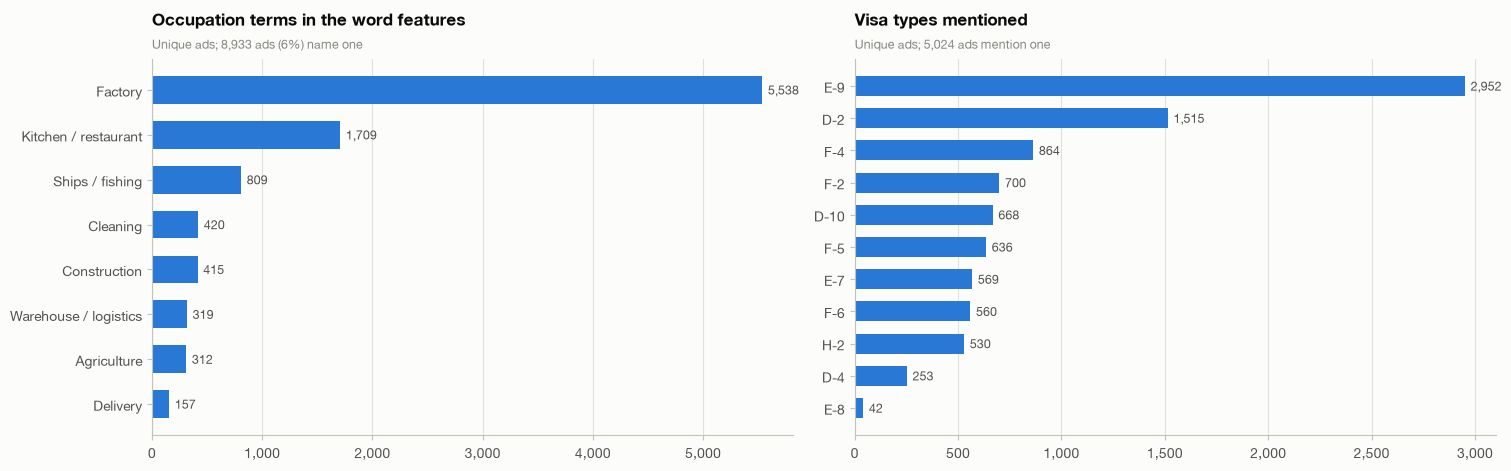

Factory                 40 terms: zavod, zavodda, zavodga, zavoda, zavodi, zavode, zavodida, zavoddan, zavodiga, zavodni, zavodlar, zavodlarda
Kitchen / restaurant    27 terms: oshxona, oshxonada, oshxonasi, oshxonaga, oshxonani, oshxonasiga, oshxonalar, oshxonasida, restoran, povar, oshxonasini, restorani
Ships / fishing         14 terms: kema, kemada, baliq, kemasozlik, kemaga, kemani, kemasozlikda, baliqchilik, baliqqa, kemasozlikka, baliqa, baliqga
Cleaning                 4 terms: uborka, tozalash, 청소, tozalashga
Construction            10 terms: qurilish, stroyka, qurilishda, stroyke, stroyku, stroykada, qurilishi, qurilishga, 건설, 건설폐기물
Warehouse / logistics   11 terms: 택배, skladda, sklad, 물류센터, skladivat, skladga, sklade, 물류, omborga, omborda, omborida
Agriculture             10 terms: dala, teplits, dalada, teplitsa, ferma, 농장, fermasi, fermada, teplitse, teplitsi
Delivery                 5 terms: dostavka, 쿠팡, kuryer, dostavki, dostavku


In [10]:
OCCUPATIONS = {
    "Factory": r"zavod\w*|fabrika\w*|factory|공장\w*|생산\w*",
    "Kitchen / restaurant": r"oshxona\w*|restoran\w*|povar\w*|ofitsiant\w*|식당\w*|주방\w*",
    "Ships / fishing": r"kemasozlik\w*|kema(?:da|ga|ni|lar\w*)?|baliq\w*|조선\w*|어선\w*",
    "Cleaning": r"tozalash\w*|uborka\w*|청소\w*",
    "Construction": r"qurilish\w*|stroyk\w*|건설\w*|노가다",
    "Warehouse / logistics": r"ombor\w*|sklad\w*|물류\w*|창고\w*|택배\w*",
    "Agriculture": r"dala|dalada|ferma\w*|teplits\w*|issiqxona\w*|농장\w*|농사\w*",
    "Delivery": r"dostavk\w*|kuryer\w*|배달\w*|쿠팡",
}
vocab = preprocessor.named_transformers_["words"][-1].get_feature_names_out()
term_index = {term: index for index, term in enumerate(vocab)}
words = block("words").tocsc()

matched_terms = {name: [term for term in vocab if re.fullmatch(pattern, term)] for name, pattern in OCCUPATIONS.items()}
occupations = pd.DataFrame(
    {name: words[:, [term_index[term] for term in terms]].getnnz(axis=1) > 0 for name, terms in matched_terms.items()}
)
occupation_counts = occupations.sum().sort_values(ascending=False)

CYRILLIC_LOOKALIKES = str.maketrans("ЕеНнФфДд", "EeHhFfDd")
VISA_PATTERN = re.compile(r"(?<!\w)([EHFD])[- ]?(10|[2-9])(?!\d)", re.IGNORECASE)
VISA_TYPES = {"E-9", "E-7", "E-8", "H-2", "F-2", "F-4", "F-5", "F-6", "D-2", "D-4", "D-10"}


def visa_mentions(text):
    body = post_body(text).translate(CYRILLIC_LOOKALIKES)
    return {f"{letter.upper()}-{number}" for letter, number in VISA_PATTERN.findall(body)} & VISA_TYPES


visas = posts["text"].map(visa_mentions)
visa_counts = visas.explode().value_counts()

fig, (ax_occupation, ax_visa) = plt.subplots(1, 2, figsize=(15, 4.6), constrained_layout=True)
for ax, counts, title, note in [
    (ax_occupation, occupation_counts, "Occupation terms in the word features",
     f"Unique ads; {occupations.any(axis=1).sum():,} ads ({occupations.any(axis=1).mean():.0%}) name one"),
    (ax_visa, visa_counts, "Visa types mentioned",
     f"Unique ads; {visas.astype(bool).sum():,} ads mention one"),
]:
    bars = ax.barh(counts.index, counts.to_numpy(), color=BLUE, height=0.62)
    ax.bar_label(bars, labels=[f"{count:,}" for count in counts], padding=4, color=INK_2, fontsize=9)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(thousands)
    ax.grid(axis="y", visible=False)
    titled(ax, title, note)
save(fig, "06_occupations_visas")
plt.show()

for name, terms in matched_terms.items():
    top_terms = sorted(terms, key=lambda term: -words[:, term_index[term]].getnnz())[:12]
    print(f"{name:<22} {len(terms):>3} terms: {', '.join(top_terms)}")

## 7. Post structure (numeric features)

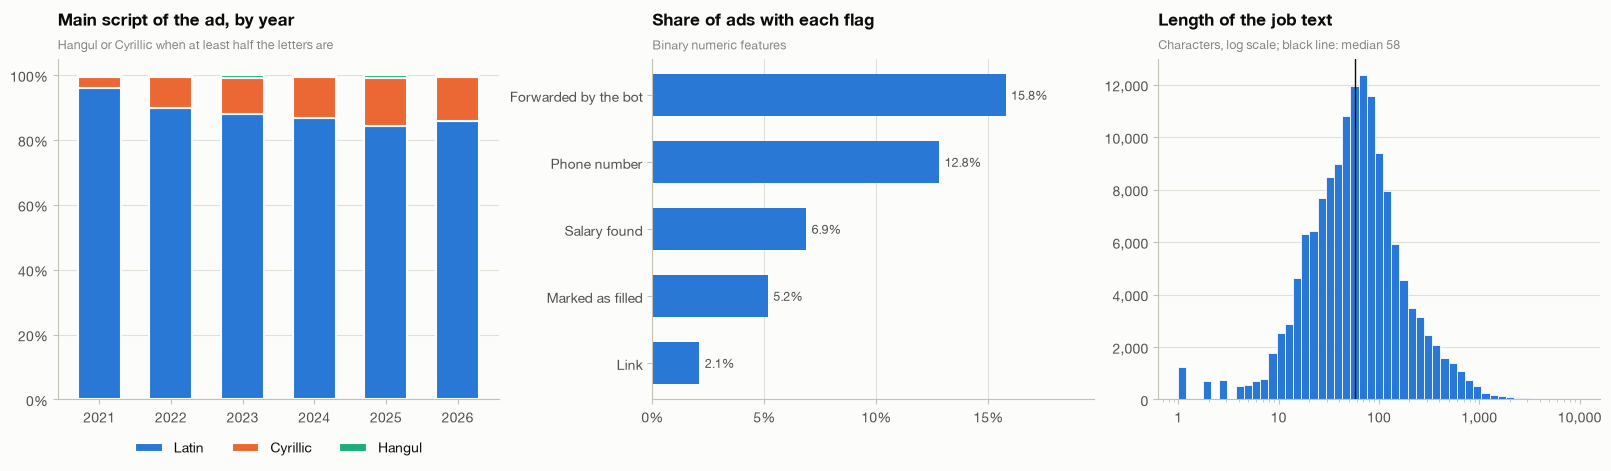

script,Latin,Cyrillic,Hangul
date,,,
2021,0.961,0.033,0.006
2022,0.899,0.094,0.007
2023,0.881,0.112,0.008
2024,0.866,0.128,0.006
2025,0.843,0.149,0.008
2026,0.858,0.137,0.004


In [11]:
features["script"] = np.select(
    [features["hangul_ratio"] >= 0.5, features["cyrillic_ratio"] >= 0.5], ["Hangul", "Cyrillic"], default="Latin"
)
SCRIPTS = {"Latin": BLUE, "Cyrillic": ORANGE, "Hangul": AQUA}
script_by_year = pd.crosstab(features["date"].dt.tz_convert("Asia/Seoul").dt.year, features["script"],
                             normalize="index").reindex(columns=list(SCRIPTS), fill_value=0)
FLAG_LABELS = {
    "has_phone": "Phone number", "has_url": "Link", "is_forwarded": "Forwarded by the bot",
    "is_filled": "Marked as filled", "has_salary": "Salary found",
}
flag_share = features[list(FLAG_LABELS)].mean().rename(FLAG_LABELS).sort_values(ascending=False)

fig, (ax_script, ax_flags, ax_length) = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)
bottom = np.zeros(len(script_by_year))
for script, color in SCRIPTS.items():
    ax_script.bar(script_by_year.index.astype(str), script_by_year[script], bottom=bottom, width=0.6, color=color,
                  edgecolor=SURFACE, linewidth=1.5, label=script)
    bottom += script_by_year[script].to_numpy()
ax_script.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax_script.grid(axis="x", visible=False)
ax_script.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)
titled(ax_script, "Main script of the ad, by year", "Hangul or Cyrillic when at least half the letters are")

bars = ax_flags.barh(flag_share.index, flag_share.to_numpy(), color=BLUE, height=0.62)
ax_flags.bar_label(bars, labels=[f"{share:.1%}" for share in flag_share], padding=4, color=INK_2, fontsize=9)
ax_flags.invert_yaxis()
ax_flags.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax_flags.xaxis.set_major_locator(MultipleLocator(0.05))
ax_flags.set_xlim(0, flag_share.max() * 1.25)
ax_flags.grid(axis="y", visible=False)
titled(ax_flags, "Share of ads with each flag", "Binary numeric features")

ax_length.hist(features["n_chars"].clip(lower=1), bins=np.logspace(0, 4, 50), color=BLUE, edgecolor=SURFACE,
               linewidth=0.6)
ax_length.set_xscale("log")
ax_length.xaxis.set_major_formatter(thousands)
ax_length.yaxis.set_major_formatter(thousands)
median_length = features["n_chars"].median()
ax_length.axvline(median_length, color=INK, linewidth=1)
ax_length.grid(axis="x", visible=False)
titled(ax_length, "Length of the job text", f"Characters, log scale; black line: median {median_length:.0f}")
save(fig, "07_post_structure")
plt.show()
script_by_year.round(3)

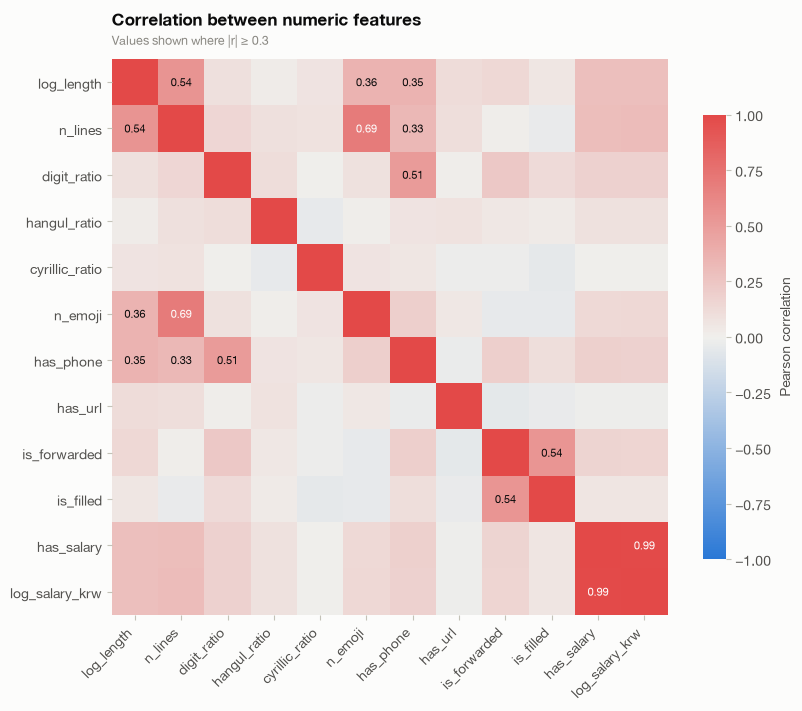

In [12]:
correlation = features[NUMERIC_FEATURES].astype(float).corr()
diverging = LinearSegmentedColormap.from_list("blue_grey_red", [BLUE, "#f0efec", "#e34948"])

fig, ax = plt.subplots(figsize=(8.5, 7), constrained_layout=True)
image = ax.imshow(correlation, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation)), correlation.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation)), correlation.index)
ax.grid(False)
ax.spines[:].set_visible(False)
for row in range(len(correlation)):
    for column in range(len(correlation)):
        value = correlation.iat[row, column]
        if row != column and abs(value) >= 0.3:
            ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(value) >= 0.6 else INK)
fig.colorbar(image, ax=ax, shrink=0.8, label="Pearson correlation").outline.set_visible(False)
titled(ax, "Correlation between numeric features", "Values shown where |r| ≥ 0.3")
save(fig, "08_numeric_correlation")
plt.show()

## 8. What the text features capture

The most common word features, and topic clusters from LSA (truncated SVD) and k-means on the word TF-IDF branch. Each cluster is labelled with the terms that are much more common inside it than across all ads.

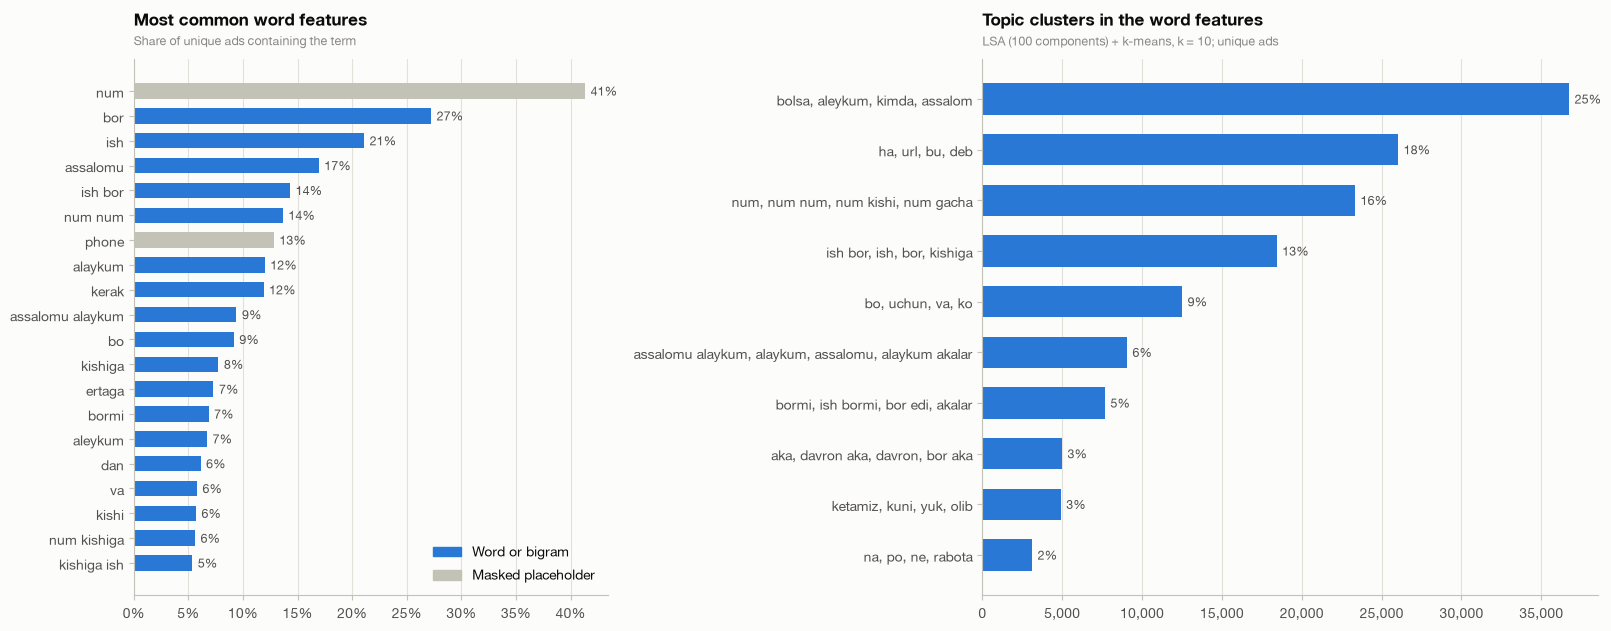

,ads,terms
0,36738,"bolsa, aleykum, kimda, assalom, akalar, edi, a..."
1,26028,"ha, url, bu, deb, lekin, men, nima, xa"
2,23333,"num, num num, num kishi, num gacha, gacha, kis..."
3,18428,"ish bor, ish, bor, kishiga, kishiga ish, num k..."
4,12506,"bo, uchun, va, ko, to, bilan, qo, ladi"
5,9048,"assalomu alaykum, alaykum, assalomu, alaykum a..."
6,7674,"bormi, ish bormi, bor edi, akalar, bormi num, ..."
7,4983,"aka, davron aka, davron, bor aka, aka num, rax..."
8,4905,"ketamiz, kuni, yuk, olib, olib ketamiz, toshke..."
9,3114,"na, po, ne, rabota, do num, yest, oplata, do"


In [13]:
PLACEHOLDERS = {"num", "phone", "url", "user", "email"}  # TextCleaner masks; TfidfVectorizer lower-cases them
document_share = words.getnnz(axis=0) / words.shape[0]
top_terms = np.argsort(-document_share)[:20]

lsa = make_pipeline(TruncatedSVD(100, random_state=0), Normalizer(copy=False))
topics = KMeans(10, n_init=4, random_state=0).fit_predict(lsa.fit_transform(block("words")))
present = (block("words") > 0).astype(np.float32)
topic_rows = []
for topic in np.unique(topics):
    share = np.asarray(present[topics == topic].mean(axis=0)).ravel()
    # Over-representation: high when a term is frequent in the cluster and rare elsewhere.
    lift = np.where(share > document_share, (share - document_share) * np.log((share + 1e-4) / (document_share + 1e-4)), 0)
    topic_rows.append({"ads": int((topics == topic).sum()), "terms": ", ".join(vocab[np.argsort(-lift)[:8]])})
topic_table = pd.DataFrame(topic_rows).sort_values("ads", ascending=False).reset_index(drop=True)

fig, (ax_terms, ax_topics) = plt.subplots(1, 2, figsize=(16, 6.2), width_ratios=[1, 1.3], constrained_layout=True)
bars = ax_terms.barh(vocab[top_terms], document_share[top_terms], height=0.62,
                     color=[GREY if vocab[index] in PLACEHOLDERS else BLUE for index in top_terms])
ax_terms.bar_label(bars, labels=[f"{share:.0%}" for share in document_share[top_terms]], padding=4, color=INK_2,
                   fontsize=9)
ax_terms.invert_yaxis()
ax_terms.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax_terms.grid(axis="y", visible=False)
ax_terms.legend(handles=[Patch(color=BLUE, label="Word or bigram"), Patch(color=GREY, label="Masked placeholder")],
                loc="lower right")
titled(ax_terms, "Most common word features", "Share of unique ads containing the term")

labels = [", ".join(terms.split(", ")[:4]) for terms in topic_table["terms"]]
bars = ax_topics.barh(labels, topic_table["ads"], color=BLUE, height=0.62)
ax_topics.bar_label(bars, labels=[f"{ads / len(posts):.0%}" for ads in topic_table["ads"]], padding=4,
                    color=INK_2, fontsize=9)
ax_topics.invert_yaxis()
ax_topics.xaxis.set_major_formatter(thousands)
ax_topics.grid(axis="y", visible=False)
titled(ax_topics, "Topic clusters in the word features", "LSA (100 components) + k-means, k = 10; unique ads")
save(fig, "09_text_features")
plt.show()
topic_table

## Findings

Numbers from the crawl up to 2026-10-03.

**The data**
- 191,083 posts with text collapse to 146,757 unique ads. 23% of posts are reposts; the 278 ads posted more than 20 times make up 8% of all posts.
- Direct group posts run at roughly 1,500–3,500 unique ads a month since early 2023. The jump to 8,711 (Aug 2026) and 13,711 (Sep 2026) is forwarded Ish e'lonlari bot posts, a new source; compare months before August 2026 on direct posts only.
- Topic clusters suggest that a good share of posts are not job offers: about 18% look like conversation ("ha, bu, deb, lekin"), 5% are people asking for work ("ish bormi"), 3% are cargo to Tashkent and 2% are in Russian. Counts in this notebook are posts, not jobs, until posts are labelled.

**Location, pay, occupations**
- 77% of provinces come from the group fallback, 16% from a place name written in Latin or Cyrillic letters and only 4% from a Korean address; 41,384 ads (28%) come from nationwide groups and get no province. The province ranking (Jeollanam-do, Gyeonggi-do, Daegu) therefore mostly mirrors which groups were crawled: 84% of Jeollanam-do ads are placed there only because they came from a Jeollanam-do group (mainly Mokpo).
- 6.9% of ads state a salary. Medians: 13,000 KRW an hour (with a spike just above the minimum wage), 135,000 a day and 2.8M a month. Median daily pay by province ranges from 120k (Gwangju) to 155k (Busan).
- 6% of ads name an occupation term; factory work dominates (5,538 ads). E-9 is the most mentioned visa (2,952 ads), then D-2 (1,515) and F-4 (864).
- Cyrillic-script ads grew from 3% (2021) to about 14% (2025–2026); Hangul-script ads stay under 1%.

**Notes on the preprocessor**
- `TfidfVectorizer` lower-cases by default, which undoes `TextCleaner`'s upper-case placeholders: `num` is the most common word feature (41% of ads) and `phone`/`user` now collide with real words. `lowercase=False` on both vectorizers would keep them apart (`TextCleaner` already lower-cases).
- The Uzbek apostrophe splits words: *bo'lsa* becomes `bo` + `lsa`, *ko'p* becomes `ko`; one whole cluster (9% of ads) forms around these fragments. Normalising `'`, `ʻ`, `’` and `` ` `` in `clean_text`, or a token pattern that keeps them inside words, would fix it.
- Greetings take up much of the vocabulary (`assalomu` 17% of ads, `alaykum` 12%); a stop-word list or `max_df` would leave room for job terms.
- `has_salary` and `log_salary_krw` correlate at 0.99, so one of them is redundant.
- `load_messages()` uses `RAW_DATA_DIR=data/raw` from `.env` relative to the working directory, so it finds no files when run from `src/notebooks` (it fails with `KeyError: 'text'`). This notebook passes `PROJECT_ROOT / settings.raw_data_dir`; resolving the path in `config/settings.py` would fix it everywhere.